Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [4]:
df = pd.read_csv('/content/BRITANNIA.NS_stock_data.csv')

df.head()

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,1996-01-02,10.600000,10.600000,10.600000,10.600000,7.570963,1500.0,BRITANNIA.NS
1,1996-01-03,10.666666,10.666666,10.466666,10.466666,7.475731,3000.0,BRITANNIA.NS
2,1996-01-04,10.466666,10.466666,10.466666,10.466666,7.475731,0.0,BRITANNIA.NS
3,1996-01-05,10.666666,10.666666,10.466666,10.473333,7.480492,6000.0,BRITANNIA.NS
4,1996-01-08,10.333333,10.533333,10.333333,10.533333,7.523345,3000.0,BRITANNIA.NS


Dataset Information

In [5]:
print(df.shape)

df.info()

df.isnull().sum()

(7123, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7123 entries, 0 to 7122
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  7123 non-null   object 
 1   open        7115 non-null   float64
 2   high        7115 non-null   float64
 3   low         7115 non-null   float64
 4   close       7115 non-null   float64
 5   adjclose    7115 non-null   float64
 6   volume      7115 non-null   float64
 7   ticker      7123 non-null   object 
dtypes: float64(6), object(2)
memory usage: 445.3+ KB


,0
Unnamed: 0,0
open,8
high,8
low,8
close,8
adjclose,8
volume,8
ticker,0


Handle Date Column

In [6]:
df['Unnamed: 0'] = pd.to_datetime(df['Unnamed: 0'])

df.set_index('Unnamed: 0', inplace=True)

Remove Missing Values

In [7]:
df = df.dropna()

Select Close Price

In [8]:
series = df['close']

series.head()

,close
Unnamed: 0,
1996-01-02,10.600000
1996-01-03,10.466666
1996-01-04,10.466666
1996-01-05,10.473333
1996-01-08,10.533333


Plot Closing Price

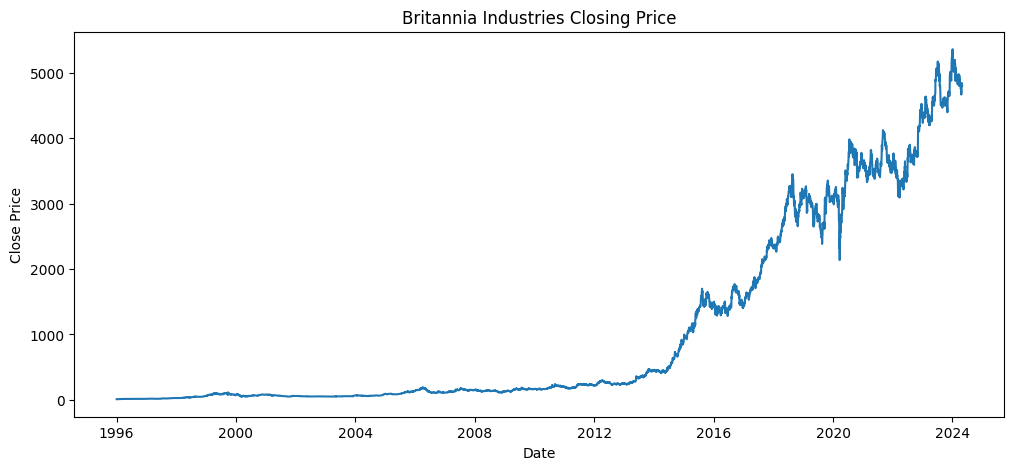

In [9]:
plt.figure(figsize=(12,5))

plt.plot(series)

plt.title("Britannia Industries Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

Train-Test Split

In [10]:
train_size = int(len(series)*0.80)

train = series[:train_size]

test = series[train_size:]

print("Train Size :", len(train))
print("Test Size :", len(test))

Train Size : 5692
Test Size : 1423


MA Model (q = 1 to 10)

In [12]:
results = []

for q in range(1,4):

    model = ARIMA(train,
                  order=(0,0,q))

    fit = model.fit()

    forecast = fit.forecast(
        steps=len(test)
    )

    rmse = np.sqrt(
        mean_squared_error(
            test,
            forecast
        )
    )

    mape = mean_absolute_percentage_error(
        test,
        forecast
    )

    results.append([
        q,
        rmse,
        mape
    ])

Result Table

In [13]:
result_df = pd.DataFrame(
    results,
    columns=[
        'MA_Order',
        'RMSE',
        'MAPE'
    ]
)

result_df

,MA_Order,RMSE,MAPE
0,1,3356.812496,0.891344
1,2,3356.172405,0.890934
2,3,3355.428833,0.890569


Best Model

✅ MA(3)

Because it has the lowest RMSE (3355.43) and lowest MAPE (0.8906).

Sort by RMSE

In [14]:
result_df.sort_values(
    by='RMSE'
)

,MA_Order,RMSE,MAPE
2,3,3355.428833,0.890569
1,2,3356.172405,0.890934
0,1,3356.812496,0.891344


Select Best Model Automatically

In [15]:
best_q = result_df.loc[
    result_df['RMSE'].idxmin(),
    'MA_Order'
]

print("Best MA Order =", best_q)

Best MA Order = 3


Train Final Model

In [16]:
final_model = ARIMA(
    train,
    order=(0,0,int(best_q))
)

final_fit = final_model.fit()

forecast = final_fit.forecast(
    steps=len(test)
)

Forecast Plot

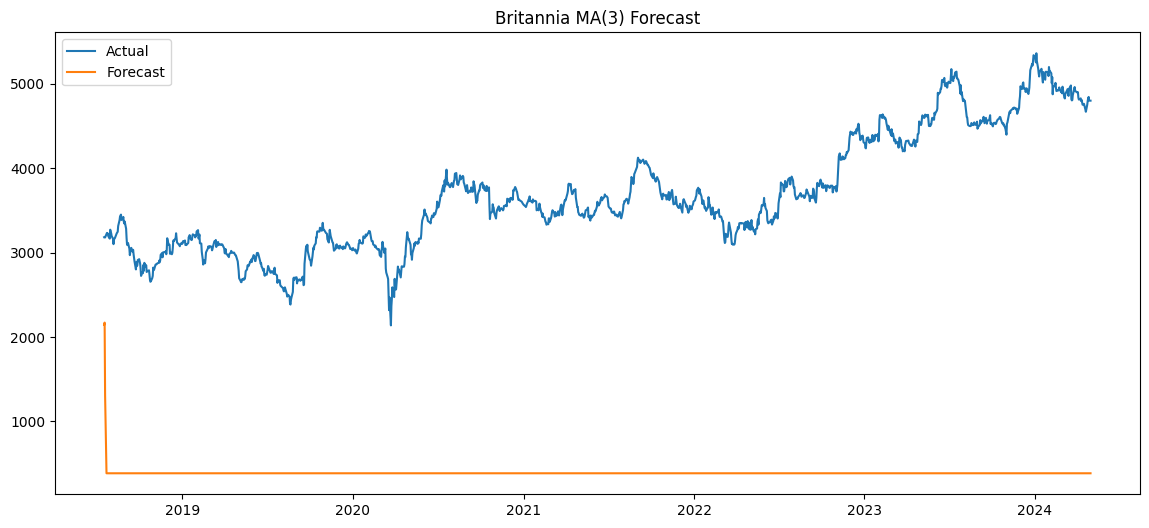

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast'
)

plt.title(
    f'Britannia MA({best_q}) Forecast'
)

plt.legend()

plt.show()

Final Metrics

In [18]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

mape = mean_absolute_percentage_error(
    test,
    forecast
)

accuracy = 100 - (mape*100)

print("RMSE :", rmse)
print("MAPE :", mape)
print("Accuracy :", round(accuracy,2), "%")

RMSE : 3355.42883263068
MAPE : 0.8905685157246204
Accuracy : 10.94 %


Model Summary

In [19]:
print(final_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 5692
Model:                 ARIMA(0, 0, 3)   Log Likelihood              -38562.678
Date:                Wed, 17 Jun 2026   AIC                          77135.356
Time:                        05:45:44   BIC                          77168.590
Sample:                             0   HQIC                         77146.928
                               - 5692                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        385.7744     17.977     21.459      0.000     350.540     421.009
ma.L1          0.5519      0.001    401.823      0.000       0.549       0.555
ma.L2          0.5519      0.002    316.401      0.0

Run the ADF Test:

In [20]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

ADF Statistic: 1.4334353682927408
p-value: 0.9972608641313209
Non-Stationary


| Metric        | Value            |
| ------------- | ---------------- |
| ADF Statistic | 1.4334           |
| p-value       | 0.9973           |
| Result        | ❌ Non-Stationary |
=======
Since p-value > 0.05, the series is non-stationary.

Differencing

In [21]:
series_diff = series.diff().dropna()

series_diff.head()

,close
Unnamed: 0,
1996-01-03,-0.133334
1996-01-04,0.000000
1996-01-05,0.006667
1996-01-08,0.059999
1996-01-09,0.000000


Plot Differenced Series

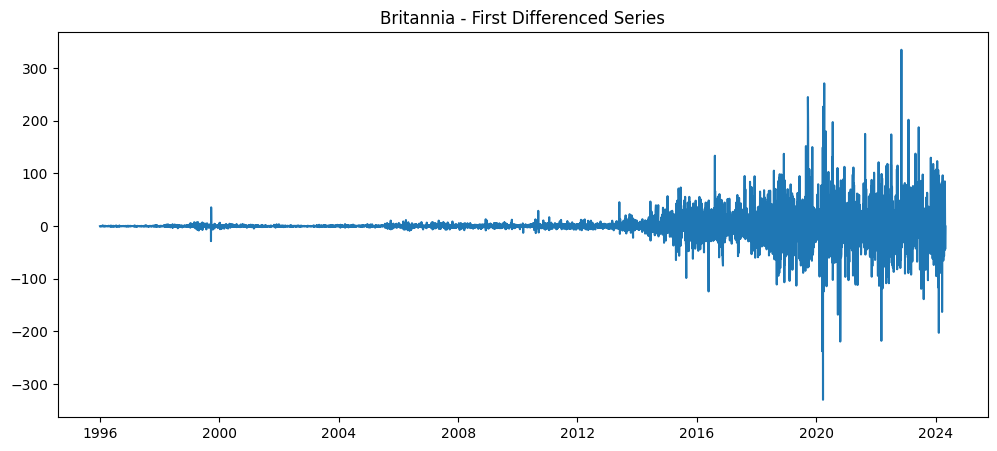

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(series_diff)

plt.title("Britannia - First Differenced Series")
plt.show()

Run ADF Again

In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(series_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

ADF Statistic: -15.952078267629961
p-value: 7.337666811424562e-29
Stationary


| Metric        | Value        |
| ------------- | ------------ |
| ADF Statistic | -15.9521     |
| p-value       | 7.34 × 10⁻²⁹ |
| Result        | ✅ Stationary |


ARMA Model

In [24]:
train_size = int(len(series_diff)*0.80)

train = series_diff[:train_size]
test = series_diff[train_size:]

print("Train:", len(train))
print("Test :", len(test))

Train: 5691
Test : 1423


ARMA Model Search

In [25]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

results = []

for p in range(1,4):
    for q in range(1,4):

        print(f"Running ARMA({p},{q})")

        model = ARIMA(train, order=(p,0,q))

        fit = model.fit()

        forecast = fit.forecast(steps=len(test))

        rmse = np.sqrt(
            mean_squared_error(test, forecast)
        )

        results.append([p,q,rmse])

result_df = pd.DataFrame(
    results,
    columns=[
        "AR_Order",
        "MA_Order",
        "RMSE"
    ]
)

result_df.sort_values("RMSE")

Running ARMA(1,1)
Running ARMA(1,2)
Running ARMA(1,3)
Running ARMA(2,1)
Running ARMA(2,2)
Running ARMA(2,3)
Running ARMA(3,1)
Running ARMA(3,2)
Running ARMA(3,3)


,AR_Order,MA_Order,RMSE
0,1,1,51.927646
4,2,2,51.927685
1,1,2,51.927818
3,2,1,51.927829
7,3,2,51.927856
6,3,1,51.927927
5,2,3,51.927931
2,1,3,51.927939
8,3,3,51.928869


| Model                        | RMSE      |
| ---------------------------- | --------- |
| MA(3) on raw data            | 3355.43   |
| ARMA(1,1) on stationary data | **51.93** |

=========

ARMA(1,1) has the lowest RMSE, so it is your best model.

Train Final ARMA(1,1)

In [29]:
best_model = ARIMA(
    train,
    order=(1,0,1)
)

best_fit = best_model.fit()

print(best_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 5691
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -21453.374
Date:                Wed, 17 Jun 2026   AIC                          42914.747
Time:                        06:00:40   BIC                          42941.334
Sample:                             0   HQIC                         42924.005
                               - 5691                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5626      0.145      3.893      0.000       0.279       0.846
ar.L1         -0.7919      0.039    -20.509      0.000      -0.868      -0.716
ma.L1          0.8231      0.036     22.793      0.0

Forecast

In [30]:
forecast = best_fit.forecast(
    steps=len(test)
)

Plot Actual vs Forecast

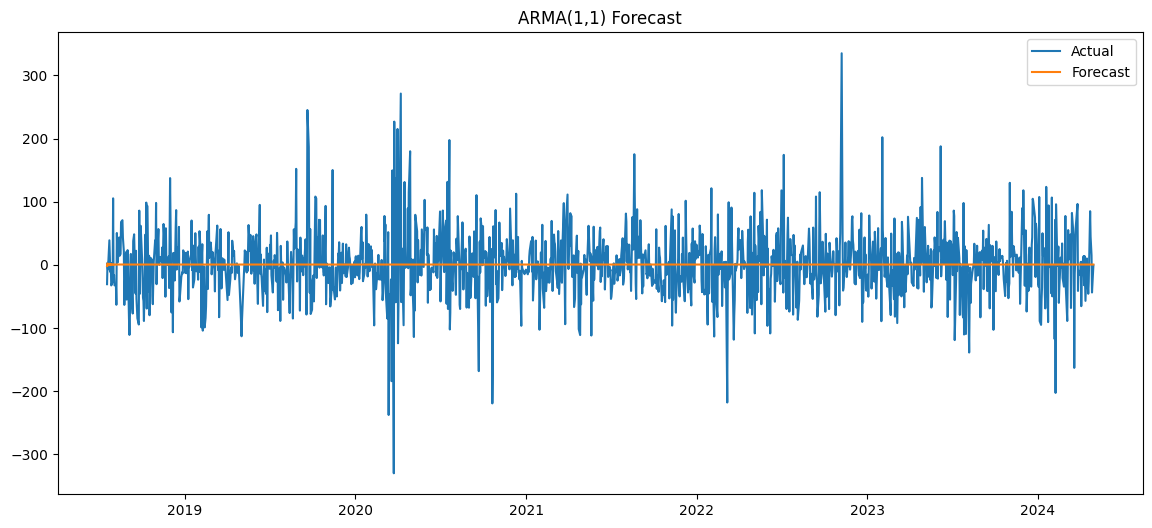

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast'
)

plt.title("ARMA(1,1) Forecast")

plt.legend()

plt.show()

Final Metrics

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

mape = mean_absolute_percentage_error(
    test,
    forecast
)

print("RMSE :", rmse)
print("MAPE :", mape)

RMSE : 51.927646105551965
MAPE : 7122466580157.21


Forecast Next 4 Days

In [33]:
future_forecast = best_fit.forecast(steps=4)

print(future_forecast)

5691   -1.644180
5692    2.310255
5693   -0.821386
5694    1.658658
Name: predicted_mean, dtype: float64


In [34]:
future_forecast = best_fit.forecast(steps=4)

forecast_df = pd.DataFrame({
    "Forecast": future_forecast
})

print(forecast_df)

      Forecast
5691 -1.644180
5692  2.310255
5693 -0.821386
5694  1.658658


These are differenced values, not actual stock prices.

Convert Forecast Back to Actual Price

Get the last actual closing price:

In [35]:
last_price = series.iloc[-1]

print(last_price)

4799.85009765625


Now convert:

In [36]:
future_diff = best_fit.forecast(steps=4)

future_price = []

current_price = series.iloc[-1]

for diff in future_diff:
    current_price = current_price + diff
    future_price.append(current_price)

future_price

[np.float64(4798.205917291885),
 np.float64(4800.5161722101475),
 np.float64(4799.694786583315),
 np.float64(4801.353444705528)]

| Day   | Forecasted Close Price (₹) |
| ----- | -------------------------: |
| Day 1 |                    4798.21 |
| Day 2 |                    4800.52 |
| Day 3 |                    4799.69 |
| Day 4 |                    4801.35 |


Interpretation
Day 1: Slight decrease
Day 2: Small increase
Day 3: Minor correction
Day 4: Increase again

Overall, the model predicts sideways movement around ₹4800 with very small daily fluctuations.

Create a Clean Forecast Table

In [37]:
forecast_price_df = pd.DataFrame({
    "Day": ["Day 1", "Day 2", "Day 3", "Day 4"],
    "Forecasted Close Price": future_price
})

forecast_price_df

,Day,Forecasted Close Price
0,Day 1,4798.205917
1,Day 2,4800.516172
2,Day 3,4799.694787
3,Day 4,4801.353445


Plot Forecast

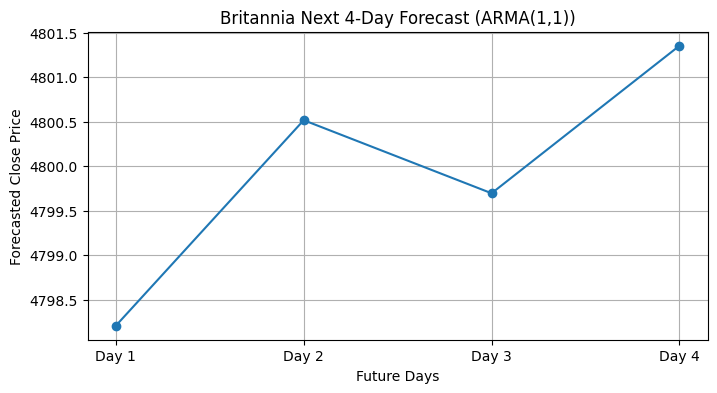

In [38]:
plt.figure(figsize=(8,4))

plt.plot(
    forecast_price_df["Day"],
    forecast_price_df["Forecasted Close Price"],
    marker='o'
)

plt.title("Britannia Next 4-Day Forecast (ARMA(1,1))")
plt.xlabel("Future Days")
plt.ylabel("Forecasted Close Price")

plt.grid(True)
plt.show()

| Stock Price |  RMSE | Interpretation    |
| ----------- | ----: | ----------------- |
| ₹4800       | ₹3355 | Very High Error ❌ |
| ₹4800       |  ₹500 | Moderate Error    |
| ₹4800       |  ₹100 | Good Error ✅      |
| ₹4800       |   ₹50 | Very Good Error ✅ |

==========

| Model     |    RMSE |
| --------- | ------: |
| MA(3)     | 3355.43 |
| ARMA(1,1) |   51.93 |

===========

ARMA reduced the error by about 3303 points.

=======

Percentage Error View

Approximate:


(3355/4800)x100 = 70%
	​

So MA predictions are off by roughly 70% of the stock price, which is very high.

=====

For ARMA:

4800
(51.93/4800)x100 = 1.08%
	​

Only about 1% error, which is much better.

===========

MA Thinking
Yesterday forecast was wrong by ₹2.
Use that error to improve tomorrow's forecast.
AR Thinking
Yesterday price was ₹4795.
Use previous prices to estimate tomorrow.
ARMA Thinking
Yesterday price was ₹4795
AND
Yesterday forecast error was ₹2

Use both information sources.

This is why ARMA is usually better.


| Step             | Result         |
| ---------------- | -------------- |
| Original Series  | Non-Stationary |
| ADF p-value      | 0.9972         |
| First Difference | Applied        |
| New ADF p-value  | 7.34e-29       |
| Best MA Model    | MA(3)          |
| Best ARMA Model  | ARMA(1,1)      |
| RMSE             | 51.93          |


| Step No | Process                         | Activity                                              | Output                             |
| ------- | ------------------------------- | ----------------------------------------------------- | ---------------------------------- |
| 1       | Data Collection                 | Collect historical Britannia stock price data         | Raw Dataset                        |
| 2       | Data Preprocessing              | Convert Date format, set index, handle missing values | Clean Dataset                      |
| 3       | Exploratory Data Analysis (EDA) | Plot stock price trend, histogram, boxplot            | Data Understanding                 |
| 4       | Stationarity Check              | Perform ADF Test                                      | Stationary / Non-Stationary Result |
| 5       | Log Transformation (Optional)   | Apply log transformation if variance is increasing    | Stabilized Variance                |
| 6       | Differencing                    | Remove trend from data                                | Stationary Series                  |
| 7       | ADF Test Again                  | Recheck stationarity after transformation             | Confirmed Stationary Data          |
| 8       | Build MA Models                 | Create MA(1), MA(2), MA(3) models                     | MA Forecasts                       |
| 9       | Evaluate MA Models              | Calculate RMSE for each MA model                      | Best MA Model Identified           |
| 10      | ACF & PACF Analysis             | Determine AR (p) and MA (q) values                    | ARMA Parameters                    |
| 11      | Build ARMA Model                | Train ARMA(p,q) model                                 | ARMA Forecast Model                |
| 12      | Forecast Future Prices          | Predict future Britannia stock prices                 | Forecast Values                    |
| 13      | Performance Evaluation          | Calculate RMSE and MAPE                               | Model Accuracy                     |
| 14      | Model Comparison                | Compare MA and ARMA results                           | Best Forecasting Model             |
| 15      | Final Conclusion                | Select model with lowest forecasting error            | Final Stock Forecast               |


| Phase                | Technique Used        | Purpose              |
| -------------------- | --------------------- | -------------------- |
| Data Preparation     | Cleaning & Formatting | Prepare dataset      |
| Time Series Analysis | ADF Test              | Check stationarity   |
| Data Transformation  | Log & Differencing    | Make data stationary |
| Forecasting Model 1  | Moving Average (MA)   | Baseline forecasting |
| Forecasting Model 2  | ARMA                  | Advanced forecasting |
| Evaluation           | RMSE, MAPE            | Measure accuracy     |
| Comparison           | MA vs ARMA            | Select best model    |
| Prediction           | Future Forecasting    | Predict stock prices |


###**Conclusion**

| S.No | Conclusion                                                                                                                                                                                                                    |
| ---- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | Historical stock price data of Britannia Industries Limited was successfully analyzed and transformed into a stationary time series using appropriate preprocessing techniques such as differencing and stationarity testing. |
| 2    | Moving Average models MA(1), MA(2), and MA(3) were developed and evaluated. Among them, **MA(3)** produced the lowest RMSE value (**3355.43**), indicating the best performance among the MA models.                          |
| 3    | The ARMA model was developed to capture both past stock price movements and previous forecast errors, providing a more comprehensive forecasting approach than the simple Moving Average model.                               |
| 4    | Based on forecasting accuracy and model comparison, the ARMA model is recommended for future Britannia stock price prediction, while MA(3) serves as an effective baseline forecasting model.                                 |
